In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = DATA_DIR / "images"


In [7]:
df = pd.read_csv(DATA_DIR / "HAM10000_metadata.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First 5 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
# Full names for each short label
label_map = {
    'akiec': 'Actinic Keratosis',
    'bcc'  : 'Basal Cell Carcinoma',
    'bkl'  : 'Benign Keratosis',
    'df'   : 'Dermatofibroma',
    'mel'  : 'Melanoma',
    'nv'   : 'Melanocytic Nevi',
    'vasc' : 'Vascular Lesion'
}

df['label_name'] = df['dx'].map(label_map)
print(df['dx'].value_counts())


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


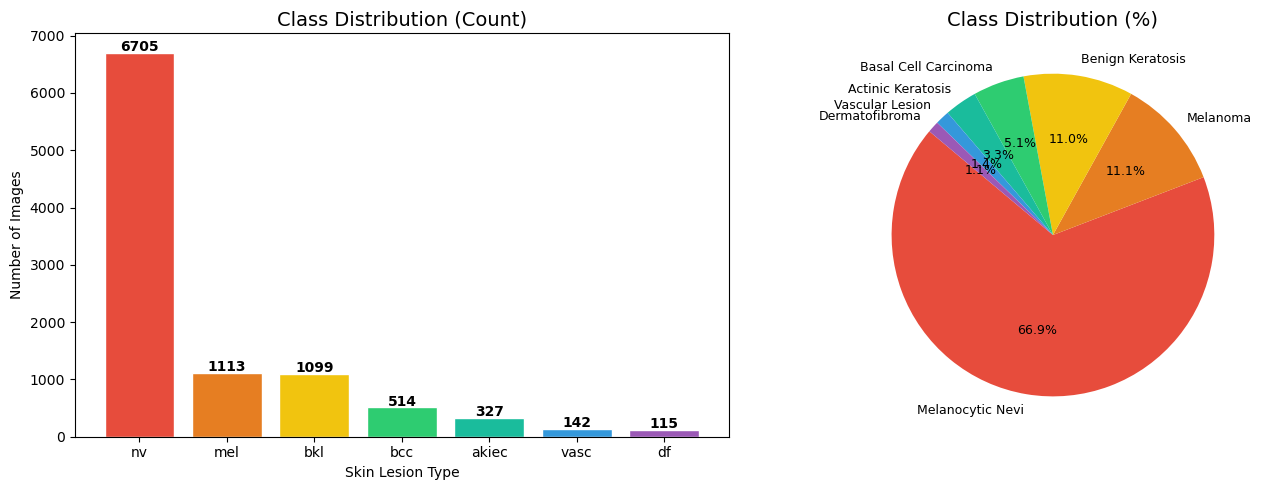


Class imbalance is CLEARLY visible — nv dominates at ~67%


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['dx'].value_counts()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6']
ax1.bar(counts.index, counts.values, color=colors, edgecolor='white')
ax1.set_title('Class Distribution (Count)', fontsize=14)
ax1.set_xlabel('Skin Lesion Type')
ax1.set_ylabel('Number of Images')
for i, (val, idx) in enumerate(zip(counts.values, counts.index)):
    ax1.text(i, val + 30, str(val), ha='center', fontsize=10, fontweight='bold')

# Pie chart
ax2.pie(counts.values, labels=[label_map[k] for k in counts.index],
        autopct='%1.1f%%', colors=colors, startangle=140,
        textprops={'fontsize': 9})
ax2.set_title('Class Distribution (%)', fontsize=14)

plt.tight_layout()
plt.savefig(DATA_DIR / "class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nClass imbalance is CLEARLY visible — nv dominates at ~67%")

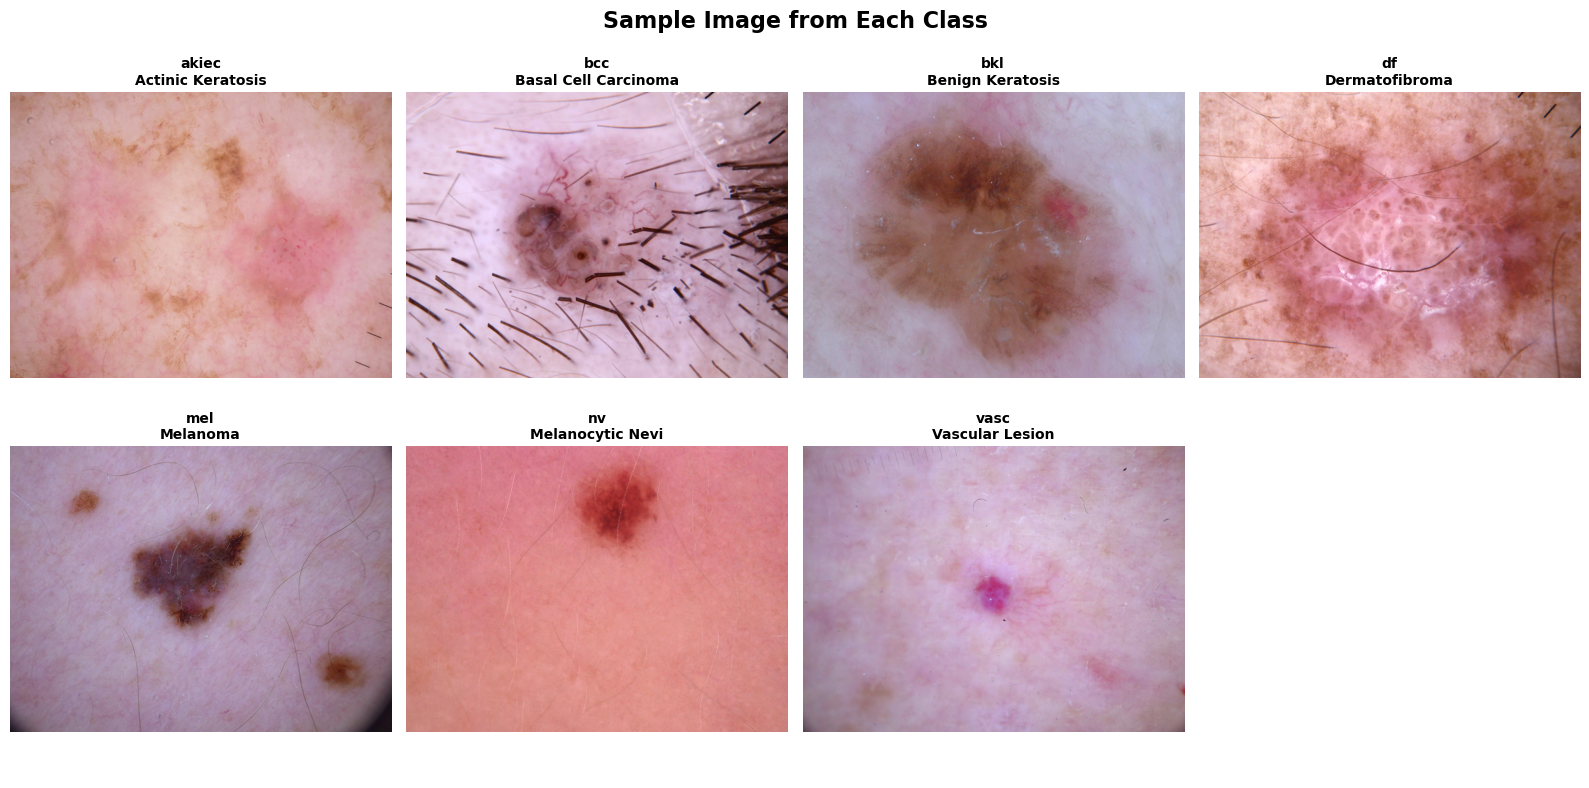

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (dx_code, full_name) in enumerate(label_map.items()):
    # Get a random image from this class
    sample = df[df['dx'] == dx_code].sample(1).iloc[0]
    img_path = IMAGES_DIR / f"{sample['image_id']}.jpg"
    
    from PIL import Image
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"{dx_code}\n{full_name}", fontsize=10, fontweight='bold')
    axes[i].axis('off')

axes[7].axis('off')  # hide last empty subplot
plt.suptitle('Sample Image from Each Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / "sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

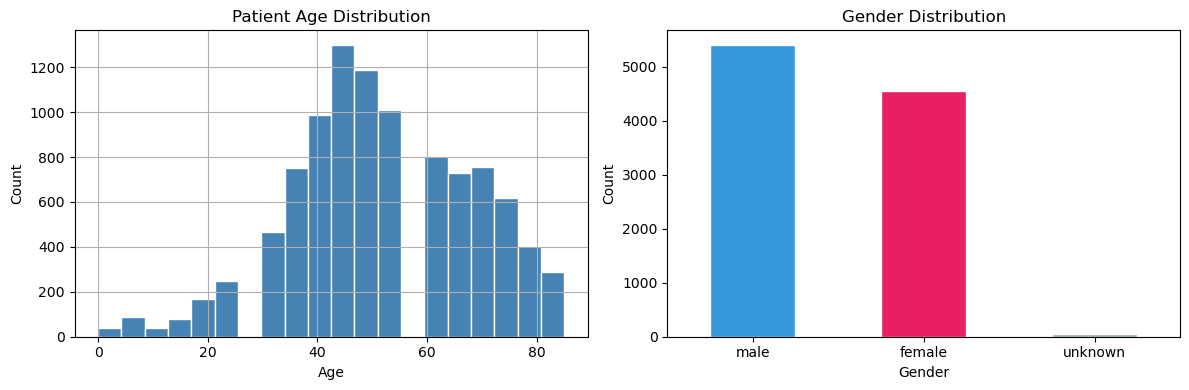

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
df['age'].dropna().hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Patient Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Gender distribution
df['sex'].value_counts().plot(kind='bar', ax=axes[1], 
    color=['#3498db','#e91e63','#95a5a6'], edgecolor='white', rot=0)
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [12]:
df['filepath'] = df['image_id'].apply(lambda x: str(IMAGES_DIR / f"{x}.jpg"))
df['file_exists'] = df['filepath'].apply(os.path.exists)

print(f"Total rows: {len(df)}")
print(f"Images found: {df['file_exists'].sum()}")
print(f"Images missing: {(~df['file_exists']).sum()}")

# Keep only rows where image exists
df = df[df['file_exists']].reset_index(drop=True)
print(f"\nWorking dataset size: {len(df)}")

Total rows: 10015
Images found: 10015
Images missing: 0

Working dataset size: 10015


In [13]:
df.to_csv(DATA_DIR / "metadata_cleaned.csv", index=False)
print("Saved metadata_cleaned.csv")

Saved metadata_cleaned.csv
